# This is where you can design your function

In DataCreator.py ive added a function called generate_data(n) where n is the amount of data. Use this function to create a large enough dataset to simulate the car and manipulate the data

In [47]:
import numpy as np
import matplotlib.pyplot as plt

from DataCreator import generate_data

#Each column is 1ms meaning 1,200,000 rows represents a 20-minute run
data = generate_data(1200000)

Design your function in this cell

Efficiency: 33.606561560923524 km/kWh
Distance: 16.535094135538987 km


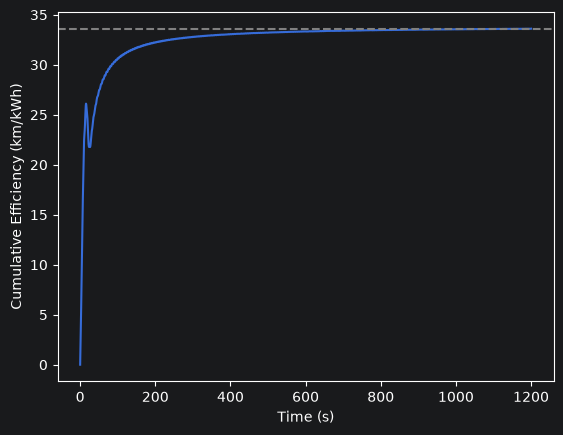

In [48]:
def my_function(df):
  #Design your function here
  time = df["time (ms)"].to_numpy() / 1000 # ms -> seconds
  current = df["current (A)"].to_numpy()
  voltage = df["voltage (V)"].to_numpy()
  speed = df["speed (km/h)"].to_numpy() / 3.6 # km/h -> m/s

  dt = np.diff(time)
  power = voltage * current # W

  # get energy and distance with trapezoid
  energy = np.cumsum(0.5 * dt * (power[1:] + power[:-1])) # J
  energy = np.insert(energy, 0, 0)
  energy /= 3600000 # J -> kWh

  distance = np.cumsum(0.5 * dt * (speed[1:] + speed[:-1])) # m
  distance = np.insert(distance, 0, 0)
  distance /= 1000 # m -> km

  total_efficiency = distance[-1] / energy[-1]
  print(f"Efficiency: {total_efficiency} km/kWh")
  print(f"Distance: {distance[-1]} km")

  with np.errstate(invalid="ignore"):
    cumulative_efficiency = np.where(energy > 0, distance / energy, 0)

  fig, ax = plt.subplots()

  ax.plot(time, cumulative_efficiency)
  ax.set_ylabel("Cumulative Efficiency (km/kWh)")
  ax.set_xlabel("Time (s)")
  ax.axhline(total_efficiency, ls="--", color="grey")

  plt.show()

my_function(data)